In [13]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import download_prices, get_log_prices
from src.signals_rolling import (
    rolling_hedge_ratio,
    compute_rolling_spread,
    compute_rolling_zscore,
    generate_positions,
)
from src.backtest import run_backtest
from src.metrics import summarize_results

In [14]:
tickers = ["KO", "PEP"]
start = "2015-01-01"
end = "2022-12-31"

prices = download_prices(tickers, start=start, end=end)
lp = get_log_prices(prices)

prices.head()


[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,29.390257,66.582947
2015-01-05,29.390257,66.082359
2015-01-06,29.613441,65.581787
2015-01-07,29.983086,67.499451
2015-01-08,30.345758,68.726219


In [ ]:
window = 60
entry = 2.0
exit = 0.5
tc_rate = 0.0002 #costs may be lower as PEP/KO are high liquidity stocks, so trading costs may be lesser
slippage_rate = 0.0005

In [26]:
hedge_ratios = rolling_hedge_ratio(lp, window=window)

spread = compute_rolling_spread(lp, hedge_ratios)

zscore = compute_rolling_zscore(spread, window=window)

positions = generate_positions(zscore, entry=entry, exit=exit)

In [27]:
results = run_backtest(
    prices=prices,
    positions=positions,
    hedge_ratios=hedge_ratios,
    tc_rate=tc_rate,
    slippage_rate=slippage_rate,
)

results.tail()

,positions,daily_pnl,cum_pnl,trading_costs,y_units,x_units
Date,,,,,,
2022-12-23,1,0.750471,19.111324,0.000421,1,-0.656122
2022-12-27,1,0.488343,19.599667,0.000553,1,-0.642467
2022-12-28,1,-0.802798,18.796869,0.000844,1,-0.621425
2022-12-29,1,-0.009284,18.787585,0.000692,1,-0.604284
2022-12-30,1,-0.987958,17.799627,0.000607,1,-0.589154


In [28]:
summary = summarize_results(results)
summary

{'total_pnl': 17.79962683576295,
 'sharpe': 0.20252243958189012,
 'max_drawdown': -22.43852522728262,
 'num_trades': 87}

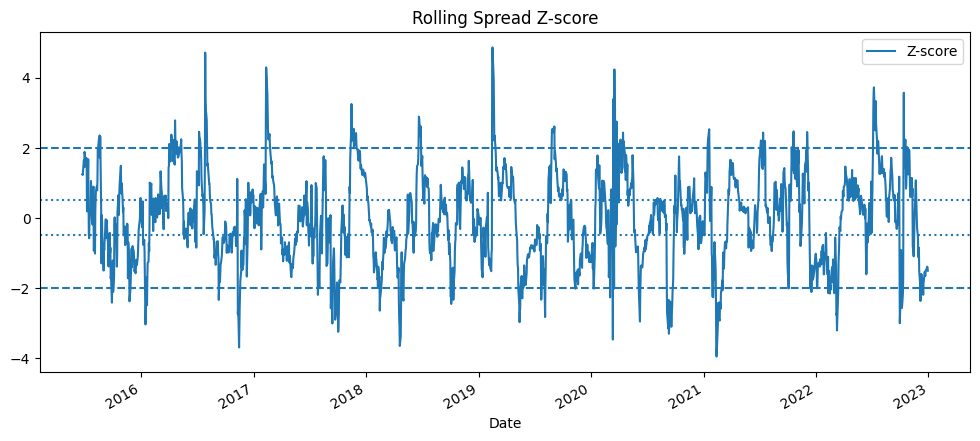

In [29]:
plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(entry, linestyle="--")
plt.axhline(-entry, linestyle="--")
plt.axhline(exit, linestyle=":")
plt.axhline(-exit, linestyle=":")
plt.title("Rolling Spread Z-score")
plt.legend()
plt.show()

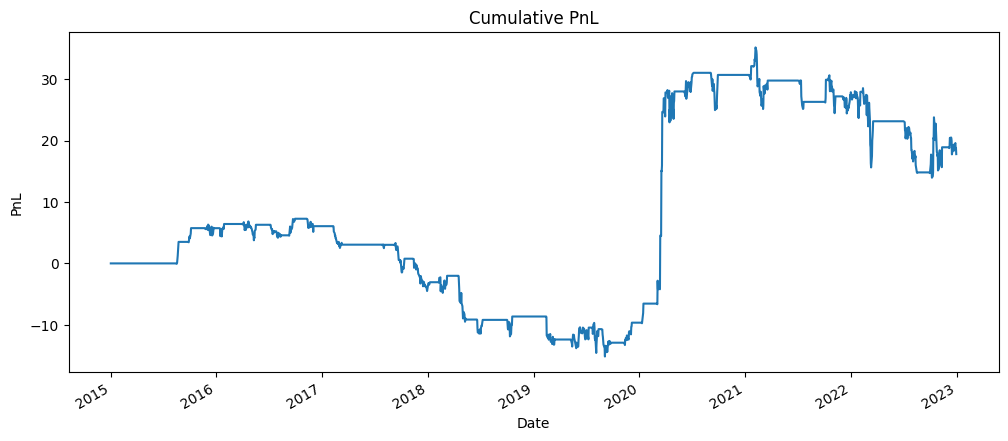

In [30]:
plt.figure(figsize=(12, 5))
results["cum_pnl"].plot()
plt.title("Cumulative PnL")
plt.ylabel("PnL")
plt.show()

In [31]:
experiments = []

for window in [30, 60, 90, 120]:
    for entry in [1.5, 2.0, 2.5]:
        hedge_ratios = rolling_hedge_ratio(lp, window=window)
        spread = compute_rolling_spread(lp, hedge_ratios)
        zscore = compute_rolling_zscore(spread, window=window)
        positions = generate_positions(zscore, entry=entry, exit=0.5)

        results = run_backtest(
            prices=prices,
            positions=positions,
            hedge_ratios=hedge_ratios,
            tc_rate=tc_rate,
            slippage_rate=slippage_rate,
        )

        summary = summarize_results(results)
        summary["window"] = window
        summary["entry"] = entry
        summary["exit"] = 0.5

        experiments.append(summary)

experiment_results = pd.DataFrame(experiments)
experiment_results.sort_values("sharpe", ascending=False)

,total_pnl,sharpe,max_drawdown,num_trades,window,entry,exit
5,23.479620,0.365812,-16.875859,50,60,2.5,0.5
4,17.799627,0.202522,-22.438525,87,60,2.0,0.5
11,11.611111,0.163612,-21.204391,34,120,2.5,0.5
7,13.646046,0.158569,-25.301055,67,90,2.0,0.5
2,8.364673,0.148244,-19.213160,74,30,2.5,0.5
8,8.907309,0.112168,-31.341770,45,90,2.5,0.5
3,6.415299,0.067825,-30.527522,119,60,1.5,0.5
0,5.486840,0.061500,-37.576479,232,30,1.5,0.5
10,4.703451,0.058282,-26.263086,50,120,2.0,0.5
1,3.593389,0.050743,-32.570699,140,30,2.0,0.5


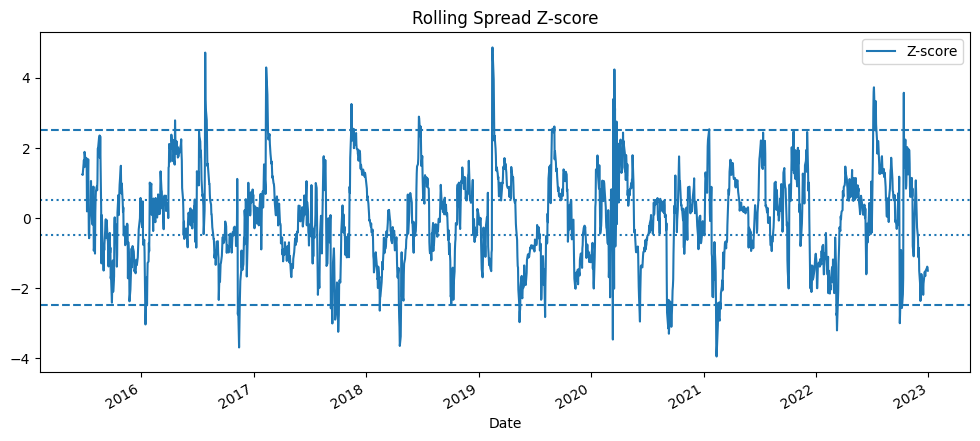

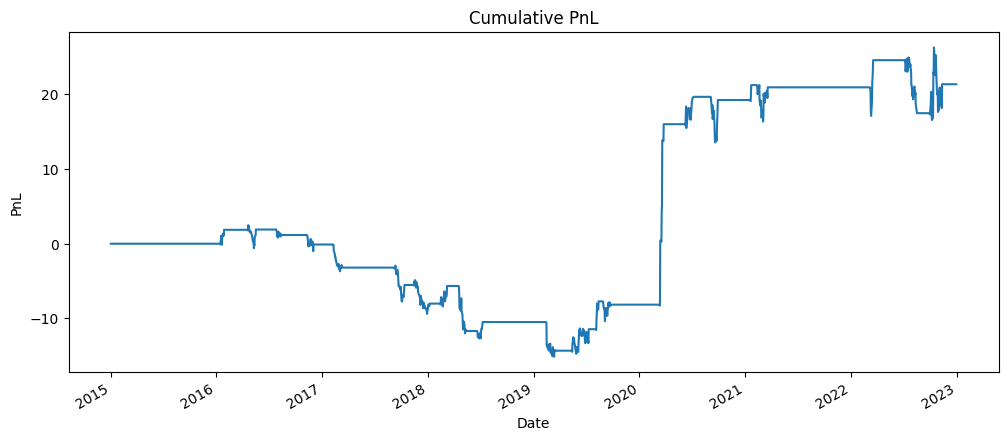

{'total_pnl': 21.37497215466541,
 'sharpe': 0.3341015768143246,
 'max_drawdown': -17.59658019193744,
 'num_trades': 50}

In [32]:
window = 60
entry = 2.5
exit = 0.5
tc_rate = 0.0005
slippage_rate = 0.0005

hedge_ratios = rolling_hedge_ratio(lp, window=window)
spread = compute_rolling_spread(lp, hedge_ratios)
zscore = compute_rolling_zscore(spread, window=window)
positions = generate_positions(zscore, entry=entry, exit=exit)

results = run_backtest(
    prices=prices, positions=positions,
    hedge_ratios=hedge_ratios, tc_rate=tc_rate, slippage_rate=slippage_rate,
)

plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(entry, linestyle="--")
plt.axhline(-entry, linestyle="--")
plt.axhline(exit, linestyle=":")
plt.axhline(-exit, linestyle=":")
plt.title("Rolling Spread Z-score")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
results["cum_pnl"].plot()
plt.title("Cumulative PnL")
plt.ylabel("PnL")
plt.show()

summary = summarize_results(results)
summary


### Investigating the sudden spike
found it was because of the sudden spike in PEP (2020-03-12) after longing the spread and also a sudden drop in it (2020-03-19) after shorting the spread

In [33]:
results.loc["2020-03-09":"2020-03-24"]

,positions,daily_pnl,cum_pnl,trading_costs,y_units,x_units
Date,,,,,,
2020-03-09,0,0.000000,-8.167409,0.000000,0,-0.000000
2020-03-10,0,0.000000,-8.167409,0.000000,0,-0.000000
2020-03-11,0,0.000000,-8.167409,0.000000,0,-0.000000
2020-03-12,1,-0.125028,-8.292437,0.125028,1,-0.779458
2020-03-13,0,8.712569,0.420131,0.136097,0,-0.000000
2020-03-16,0,0.000000,0.420131,0.000000,0,-0.000000
2020-03-17,-1,-0.138154,0.281978,0.138154,-1,0.847733
2020-03-18,-1,3.954605,4.236583,0.001833,-1,0.798374
2020-03-19,-1,0.946294,5.182877,0.001195,-1,0.763885


In [34]:
prices.loc["2020-03-09":"2020-03-24"]

Ticker,KO,PEP
Date,,
2020-03-09,42.571846,107.039650
2020-03-10,44.049465,110.312706
2020-03-11,42.859161,106.702484
2020-03-12,38.713619,94.852135
2020-03-13,40.137959,104.811012
2020-03-16,37.479755,93.001801
2020-03-17,39.069702,105.033066
2020-03-18,37.140228,99.440948
2020-03-19,34.639381,96.496849
